---
title: Multivariate > Hierarchical Clustering
jupyter: python3
---

<div class="alert alert-info">Determine the appropriate number of segments by grouping similar observations together in a stepwise, hierarchical process.</div>

The goal of Cluster Analysis is to group respondents (e.g., consumers) into segments based on needs, benefits, and/or behaviors. The tool tries to achieve this goal by looking for respondents that are similar, putting them together in a cluster or segment, and separating them from other, dissimilar, respondents. The researcher compares the segments and provides a descriptive label for each.

Hierarchical Cluster Analysis is most often used as a *diagnostic* tool: it helps us decide **how many** segments exist in the data before we commit to a final solution (which can then be refined with, e.g., K-means). The key outputs are the plots, so we will focus most of our attention there.

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Example: Shopping attitudes

The `shopping` dataset contains responses from 20 consumers who were asked a set of questions to determine their attitudes towards shopping. The scores shown for variables `v1`-`v6` indicate the level of agreement with statements on a scale where larger values mean stronger agreement. We want to find groups of shoppers with similar attitudes.

In Radiant you would load this through *Data > Manage*. In the notebook workflow we read the parquet file directly from GitHub.

In [3]:
shopping = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/shopping.parquet"
)
shopping.head()

id,v1,v2,v3,v4,v5,v6
i32,i32,i32,i32,i32,i32,i32
1,6,4,7,3,2,3
2,2,3,1,4,5,4
3,7,2,6,4,1,3
4,4,6,4,5,3,6
5,1,3,2,2,6,4


## Distance and linkage choices

We first establish the number of segments/clusters in the data using Hierarchical Cluster Analysis. Ward's method (`method="ward.D"`) with Squared Euclidean distance (`distance="sq.euclidian"`) is often used to determine how (dis)similar individuals are. These are the default values and they can be changed if desired.

The `hclus` tool takes a dictionary that maps a dataset name to a (Polars or Pandas) data frame and a `vars` argument. You can pass variables as a list (e.g., `["v1", "v2", "v3"]`) or use the `"v1:v6"` short-hand to select a contiguous range of columns.

In [4]:
hc = rsm.multivariate.hclus({"shopping": shopping}, vars="v1:v6")
hc.summary()

Hierarchical cluster analysis
Data        : shopping
Variables   : v1, v2, v3, v4, v5, v6
Method      : ward.D
Distance    : sq.euclidian
Standardize : True
Observations: 20


The summary echoes the choices made by the algorithm:

* **Method** — the linkage rule used to merge groups. The default is `ward.D`. Other options are `ward.D2`, `single`, `complete`, `average`, `centroid`, and `median`. Ward's method tends to produce compact, roughly equal-sized clusters and is a sensible default for segmentation.
* **Distance** — how (dis)similarity between observations is measured. The default is `sq.euclidian` (squared Euclidean). Other options include `euclidean`, `manhattan`, and `binary`/`jaccard`. When categorical variables are included, `gower` distance is selected automatically (see below).
* **Standardize** — whether variables are rescaled before the distances are computed (`standardize=True` by default; more on this next).

## Standardization

By default, data are standardized before they are analyzed. This matters because distance-based clustering is sensitive to the scale of each variable: a variable measured on a 1-100 scale would otherwise dominate one measured on a 1-7 scale, regardless of which variable is more relevant for segmentation. Standardizing puts every variable on a comparable footing so that each contributes meaningfully to the distance calculation.

To pass data in its raw form to the estimation algorithm, set `standardize=False`. Here all six items use the same response scale, so the standardized and raw solutions will be similar, but standardizing remains good practice and is the default.

In [5]:
hc_raw = rsm.multivariate.hclus({"shopping": shopping}, vars="v1:v6", standardize=False)
hc_raw.summary()

Hierarchical cluster analysis
Data        : shopping
Variables   : v1, v2, v3, v4, v5, v6
Method      : ward.D
Distance    : sq.euclidian
Standardize : False
Observations: 20


## Reading the dendrogram

Hierarchical cluster analysis starts with many segments — as many as there are respondents — and in a stepwise (i.e., hierarchical) process adds the most similar respondents or groups together until only one segment remains. The Dendrogram below provides information to help you determine the most appropriate number of clusters (or segments).

To determine the appropriate number of segments look for a *jump* along the vertical axis of the plot. At that point two dissimilar segments have been joined. The measure along the vertical axis indicates the level of heterogeneity **within** the segments that have been formed. The purpose of clustering is to create homogeneous groups and to avoid segments with heterogeneous characteristics, needs, etc.

Setting `cutoff=0` shows the full tree so that every merge is visible.

In [6]:
hc.plot(plots="dendro", cutoff=0)

<Figure size 640x480 with 1 Axes>

Read the dendrogram from the bottom up. Each respondent starts as its own leaf, and branches join as you move up the tree. The *height* at which two branches join is how dissimilar they are. A long vertical branch (a big "jump") indicates that two quite different groups were forced together — a signal that you have probably gone one merge too far. For the shopping data the most obvious jump occurs when we go from 3 to 2 segments, so we would choose **3 segments** (i.e., we avoid creating a heterogeneous segment).

## Picking the number of clusters with scree and change plots

Another way to determine the number of segments is a scree-plot. This is a plot of the within-cluster heterogeneity on the vertical axis and the number of segments on the horizontal axis. Again, hierarchical cluster analysis starts with many segments and groups respondents together until only one segment is left.

If `cutoff` is set to `0` we see results for all possible cluster solutions. To make the plot easier to evaluate, we can set `cutoff` to, for example, `0.05` (i.e., show only solutions that have `Within-cluster heterogeneity` above 5%). The heterogeneity values are normalized to a 0-1 scale, so the cutoff is interpreted as a fraction.

The `change` plot shows the *change* in within-cluster heterogeneity from one solution to the next, which makes the size of each "jump" explicit.

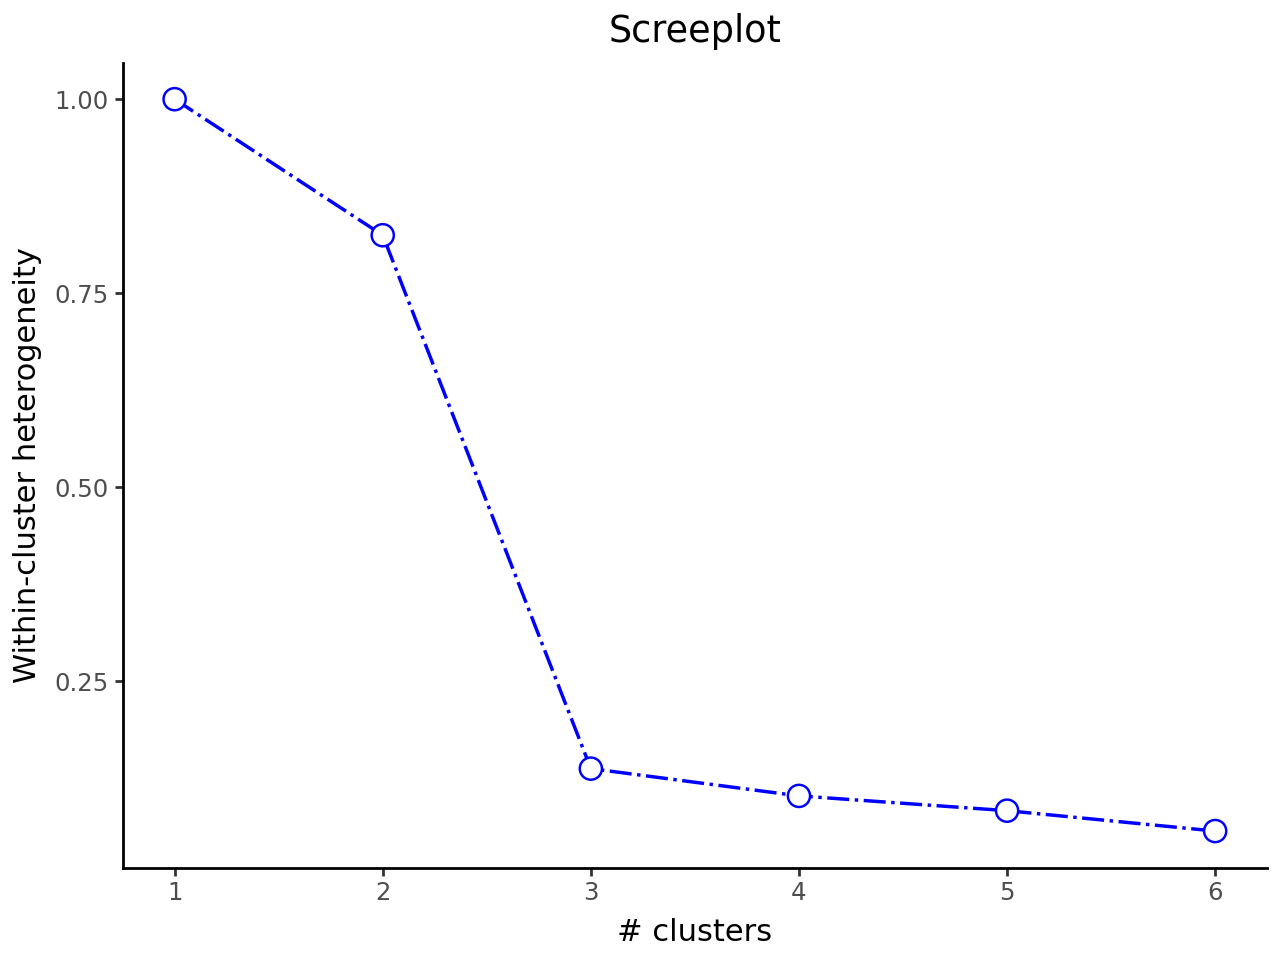

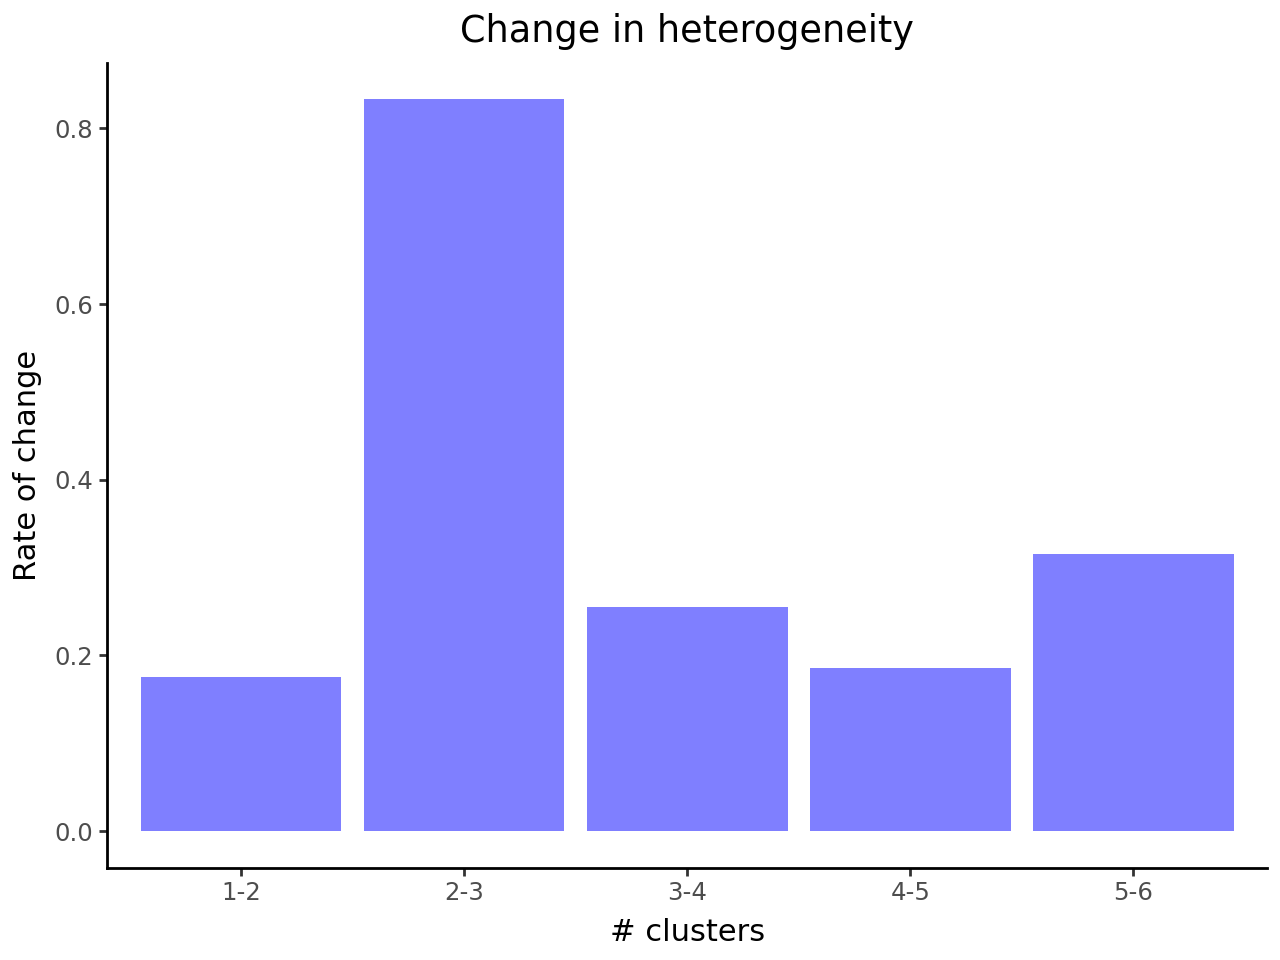

In [7]:
hc.plot(plots=["scree", "change"], cutoff=0.05)

Reading the scree plot from left-to-right we look for the point where within-segment heterogeneity increases sharply — for the shopping data this is the move from 3 to 2 segments. This is also clear from the `Change in within-cluster heterogeneity` plot: the tallest bar marks the merge that combined two genuinely dissimilar groups. To avoid creating a heterogeneous segment we, again, choose **3 segments**.

> Note: Hierarchical cluster analysis can be time-consuming and memory intensive for large datasets. If your dataset has more than 5,000 observations, increase the `max_cases` argument to the appropriate number.

## Storing cluster membership

Hierarchical cluster analysis generates numerous clustering solutions. The highest number of clusters is equal to the number of observations in the data (every respondent is treated as a separate cluster). The lowest number of clusters evaluated is 1 (all respondents grouped together in a single cluster).

Although HC analysis is often used as a diagnostic tool before generating a final solution using, e.g., K-means, we can also store any specific clustering solution it generates. Now that we have decided on 3 segments, use `store` to append the cluster assignment to the data. By default the new column is named `hclus<nr_clus>` (here `hclus3`); pass `name="..."` to choose your own.

In [8]:
clustered = hc.store(shopping, nr_clus=3)
clustered.head()

id,v1,v2,v3,v4,v5,v6,hclus3
i32,i32,i32,i32,i32,i32,i32,cat
1,6,4,7,3,2,3,"""1"""
2,2,3,1,4,5,4,"""2"""
3,7,2,6,4,1,3,"""1"""
4,4,6,4,5,3,6,"""3"""
5,1,3,2,2,6,4,"""2"""


The new `hclus3` column labels each respondent with their segment number. We can count how many respondents fall in each segment:

In [9]:
clustered["hclus3"].value_counts()

hclus3,count
cat,u32
"""3""",6
"""2""",6
"""1""",8


With assignments in hand you would profile each segment — for example by comparing the average score on each attitude item across clusters — and give each segment a descriptive, marketing-friendly label.

## Working with the underlying attributes

The fitted object exposes the building blocks of the analysis directly, which is useful for custom plots or downstream analysis:

* `hc.linkage` — the SciPy-style linkage matrix (one row per merge).
* `hc.height` — the merge heights on R's scale (the values plotted on the dendrogram's vertical axis).
* `hc.cutree(k)` — cluster assignments for a `k`-cluster solution (the engine behind `store`).
* `hc.distance` — the distance metric actually used.

In [10]:
print("distance used:", hc.distance)
print("linkage matrix shape:", hc.linkage.shape)
print("number of merge heights:", len(hc.height))
print("3-cluster assignment:", hc.cutree(3))

distance used: sq.euclidian
linkage matrix shape: (19, 4)
number of merge heights: 19
3-cluster assignment: [1 2 1 3 2 1 1 1 2 3 2 1 2 3 1 3 1 3 3 2]


## Mixed numeric and categorical data: Gower distance

If the data used for clustering includes categorical (factor) variables, the `gower` distance is automatically selected. Gower distance can handle a mix of numeric and categorical variables in a single dissimilarity measure, which Euclidean-type distances cannot.

The `toothpaste` dataset contains responses from 60 consumers, including the numeric attitude items `v1`-`v6` and the categorical variable `gender`. When we include `gender` in the variable list, `hclus` switches to Gower distance without any extra configuration.

In [11]:
toothpaste = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/toothpaste.parquet"
)
toothpaste.head()

id,v1,v2,v3,v4,v5,v6,age,age.cat,gender
i32,i32,i32,i32,i32,i32,i32,i32,enum,enum
1,7,3,6,4,2,4,50,"""> 40""","""Female"""
2,1,3,2,4,5,4,27,"""< 30""","""Female"""
3,6,2,7,4,1,3,24,"""< 30""","""Female"""
4,4,5,4,6,2,5,21,"""< 30""","""Female"""
5,1,2,2,3,6,2,34,"""30 to 39""","""Female"""


In [12]:
hcm = rsm.multivariate.hclus(
    {"toothpaste": toothpaste}, vars=["v1", "v2", "v3", "gender"]
)
hcm.summary()

** Categorical variables selected; using Gower distance **
Hierarchical cluster analysis
Data        : toothpaste
Variables   : v1, v2, v3, gender
Method      : ward.D
Distance    : gower
Standardize : True
Observations: 60


Notice that the summary now reports `Distance: gower`. The rest of the workflow is identical — read the dendrogram and scree/change plots, choose a number of clusters, and store the solution.

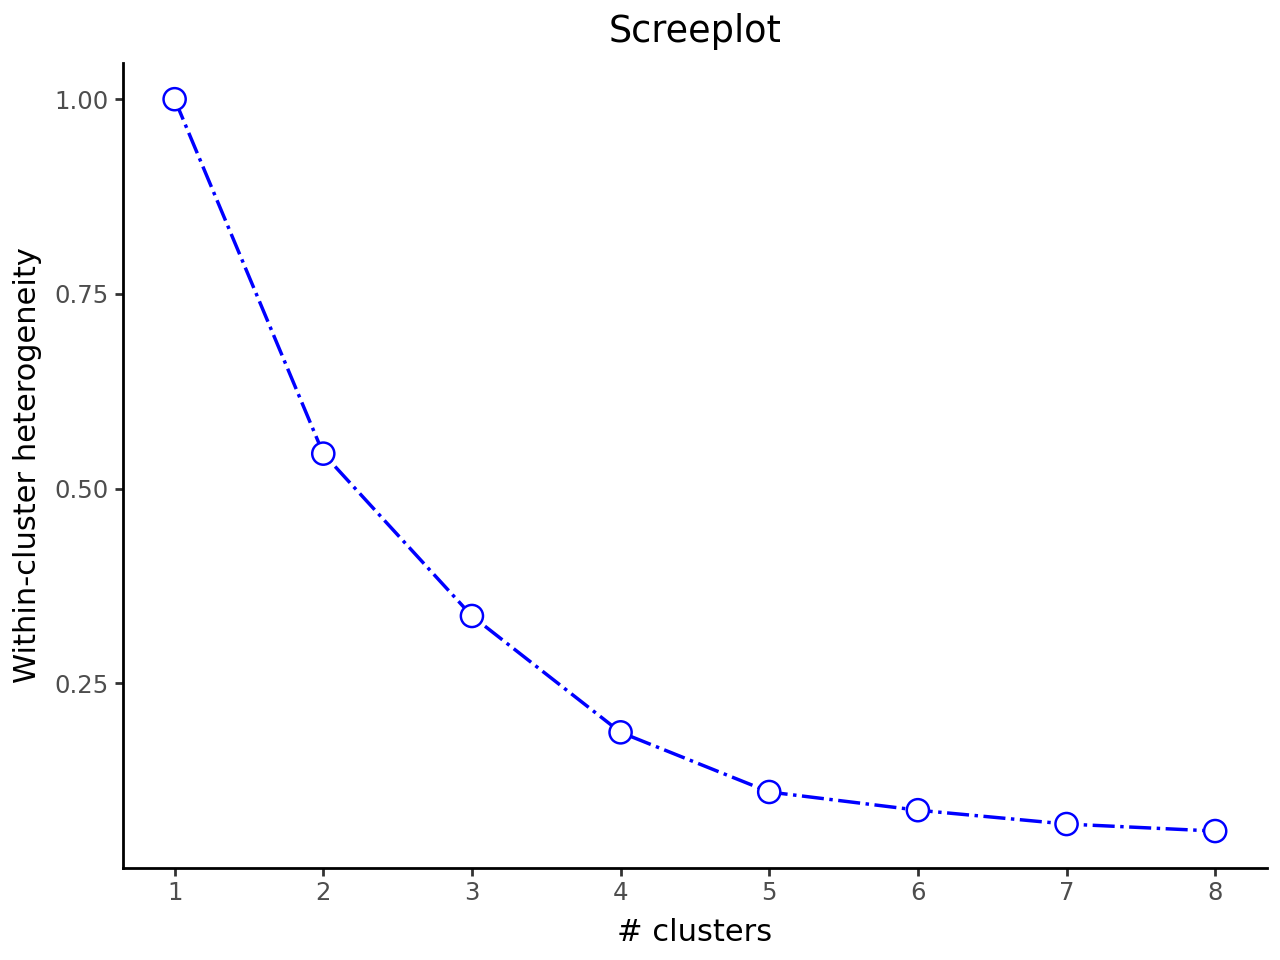

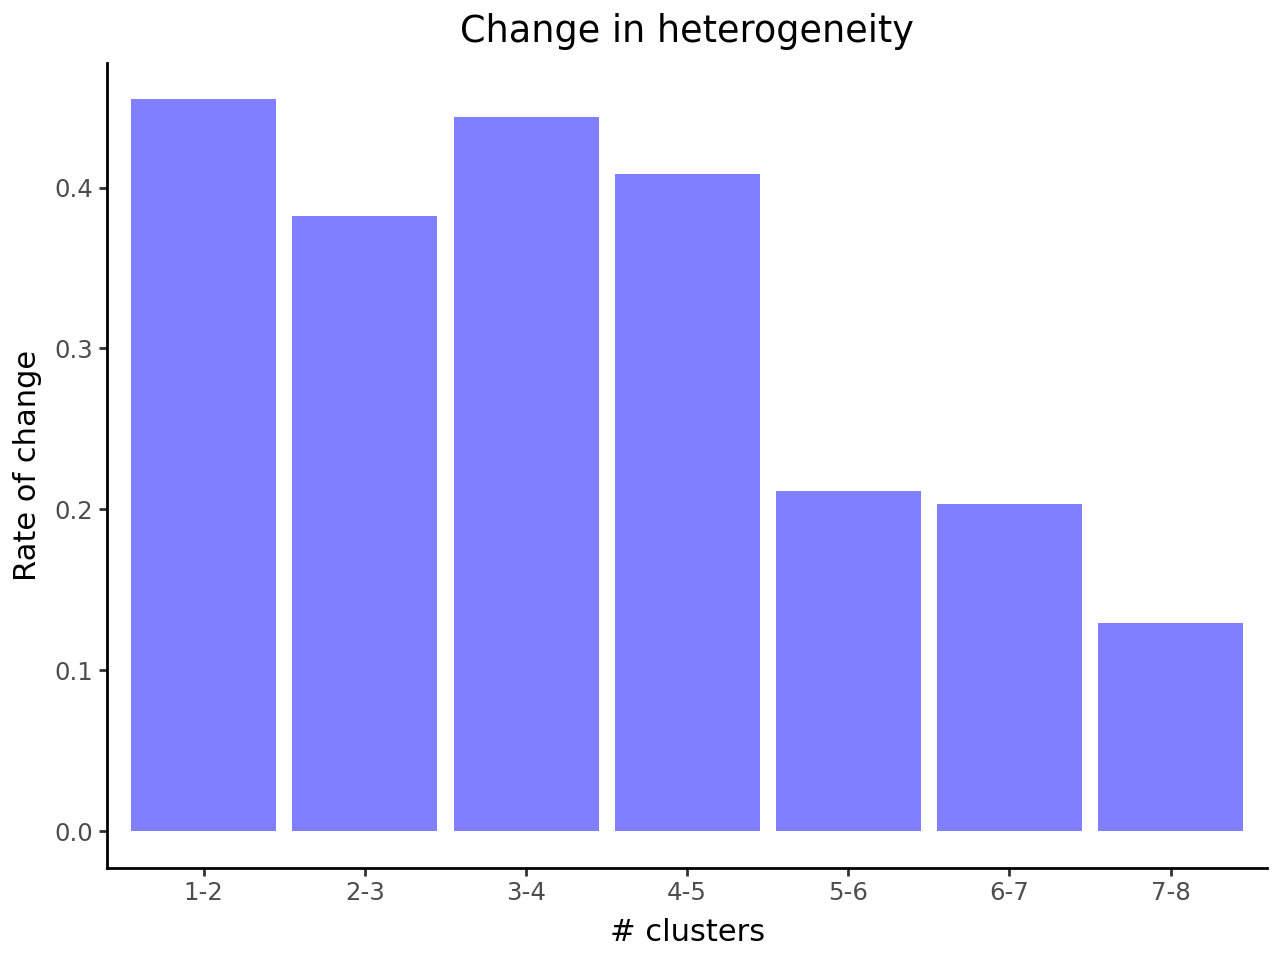

In [13]:
hcm.plot(plots=["scree", "change"], cutoff=0.05)

In [14]:
print("distance used:", hcm.distance)

distance used: gower


For more information on the Gower distance, see the Gower R-package <a href="https://cran.r-project.org/web/packages/gower/vignettes/intro.pdf" target="_blank">package vignette</a>.

## Next steps

Once you have determined the appropriate number of segments to extract, you can generate the final cluster solution. Hierarchical clustering is a natural first step; a common follow-up is K-means clustering (`rsm.multivariate.kclus`), which can be initialized from the hierarchical centers to refine the segments and report cluster means on the original scale.

## Discussion prompts

* How do the dendrogram, scree, and change plots agree (or disagree) on the number of clusters for the shopping data?
* How does turning standardization off change which variables drive the clusters?
* For the toothpaste example, how does adding a categorical variable (and therefore switching to Gower distance) change your reading of the solution?
* How would you describe and label each segment so that a marketing team could act on it?